# 04 — Modeling: Random Forest vs SVM

**Input:** `data/processed/btk_fps.csv` (9.436 molecules × 2.048 bits)  
**Output:** trained models in `models/`, metrics in `results/`

Steps:
1. Load fingerprint dataset
2. Train/test split (stratified)
3. Train Random Forest with 5-fold stratified cross-validation
4. Train SVM with 5-fold stratified cross-validation
5. Compare CV results
6. Evaluate both models on the held-out test set
7. Save trained models

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, confusion_matrix, classification_report,
    RocCurveDisplay
)

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {df.shape[0]} molecules, {df.shape[1]} columns')

Loaded: 9436 molecules, 2051 columns


## 2. Prepare X and y

In [2]:
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['activity'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Class balance: {np.bincount(y)} (0=inactive, 1=active)')
print(f'Class %: {np.bincount(y)/len(y)*100}')

X shape: (9436, 2048)
y shape: (9436,)
Class balance: [ 802 8634] (0=inactive, 1=active)
Class %: [ 8.49936414 91.50063586]


## 3. Train/Test Split (Stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules — class balance: {np.bincount(y_train)}')
print(f'Test set:  {X_test.shape[0]} molecules — class balance: {np.bincount(y_test)}')

Train set: 7548 molecules — class balance: [ 642 6906]
Test set:  1888 molecules — class balance: [ 160 1728]


## 4. Cross-Validation Setup

Note: `matthews_corrcoef` is included as an additional metric alongside AUC,
F1, precision, and recall. With a severe class imbalance (91.5% active /
8.5% inactive), MCC is more informative than F1 alone because it accounts
for all four quadrants of the confusion matrix symmetrically.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'mcc': 'matthews_corrcoef'
}

print('Cross-validation configured: 5-fold, stratified')
print('Metrics: AUC, F1, Precision, Recall, MCC')

Cross-validation configured: 5-fold, stratified
Metrics: AUC, F1, Precision, Recall, MCC


## 5. Random Forest — Cross-Validation

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Running 5-fold cross-validation for Random Forest...')
rf_cv_results = cross_validate(rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== Random Forest — Cross-Validation Results ===')
for metric in scoring:
    scores = rf_cv_results[f'test_{metric}']
    print(f'{metric.upper():10s}: {scores.mean():.3f} ± {scores.std():.3f}')

Running 5-fold cross-validation for Random Forest...

=== Random Forest — Cross-Validation Results ===
AUC       : 0.922 ± 0.012
F1        : 0.961 ± 0.003
PRECISION : 0.961 ± 0.005
RECALL    : 0.961 ± 0.004
MCC       : 0.537 ± 0.045


## 6. SVM — Cross-Validation

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

# SVM is computationally expensive with large datasets.
# We train on a stratified subsample (3000 molecules) to keep runtime feasible
# while preserving the class distribution.
sss = StratifiedShuffleSplit(n_splits=1, train_size=3000, random_state=RANDOM_STATE)
idx_sub, _ = next(sss.split(X_train, y_train))
X_train_svm = X_train[idx_sub]
y_train_svm = y_train[idx_sub]

print(f'SVM subsample: {len(y_train_svm)} molecules — class balance: {np.bincount(y_train_svm)}')

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    ))
])

print('Running 5-fold cross-validation for SVM (subsampled to n=3000)...')
svm_cv_results = cross_validate(svm, X_train_svm, y_train_svm, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== SVM — Cross-Validation Results (subsample n=3000) ===')
for metric in scoring:
    scores = svm_cv_results[f'test_{metric}']
    print(f'{metric.upper():10s}: {scores.mean():.3f} ± {scores.std():.3f}')

SVM subsample: 3000 molecules — class balance: [ 255 2745]
Running 5-fold cross-validation for SVM (subsampled to n=3000)...

=== SVM — Cross-Validation Results (subsample n=3000) ===
AUC       : 0.853 ± 0.015
F1        : 0.950 ± 0.003
PRECISION : 0.940 ± 0.003
RECALL    : 0.961 ± 0.006
MCC       : 0.341 ± 0.038


## 7. Compare CV Results — RF vs SVM

=== CV Comparison (mean across 5 folds) ===
           Random Forest    SVM
AUC                0.922  0.853
F1                 0.961  0.950
PRECISION          0.961  0.940
RECALL             0.961  0.961
MCC                0.537  0.341


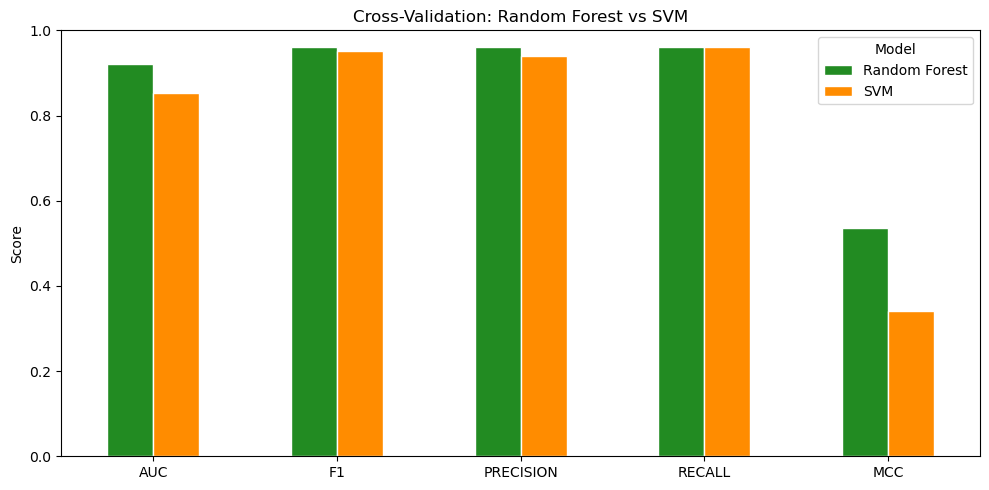

Plot saved to results/


In [7]:
comparison = pd.DataFrame({
    'Random Forest': [rf_cv_results[f'test_{m}'].mean() for m in scoring],
    'SVM':           [svm_cv_results[f'test_{m}'].mean() for m in scoring],
}, index=[m.upper() for m in scoring])

print('=== CV Comparison (mean across 5 folds) ===')
print(comparison.round(3))

comparison.plot(kind='bar', figsize=(10, 5), color=['forestgreen', 'darkorange'], edgecolor='white')
plt.title('Cross-Validation: Random Forest vs SVM')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('../results/04_cv_comparison.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 8. Final Training and Test Set Evaluation

In [8]:
rf.fit(X_train, y_train)
svm.fit(X_train_svm, y_train_svm)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

svm_pred  = svm.predict(X_test)
svm_proba = svm.predict_proba(X_test)[:, 1]

print('Models trained on full training set.')

c:\Users\Giovanna\miniconda3\envs\qsar-proj1\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Models trained on full training set.


In [9]:
def print_test_metrics(name, y_true, y_pred, y_proba):
    auc       = roc_auc_score(y_true, y_proba)
    f1        = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    mcc       = matthews_corrcoef(y_true, y_pred)

    print(f'=== {name} — Test Set Performance ===')
    print(f'AUC-ROC:   {auc:.3f}')
    print(f'F1-score:  {f1:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall:    {recall:.3f}')
    print(f'MCC:       {mcc:.3f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Inactive', 'Active']))
    print()
    return auc, f1, mcc

rf_auc, rf_f1, rf_mcc   = print_test_metrics('Random Forest', y_test, rf_pred, rf_proba)
svm_auc, svm_f1, svm_mcc = print_test_metrics('SVM', y_test, svm_pred, svm_proba)

=== Random Forest — Test Set Performance ===
AUC-ROC:   0.928
F1-score:  0.957
Precision: 0.967
Recall:    0.947
MCC:       0.547

              precision    recall  f1-score   support

    Inactive       0.53      0.65      0.59       160
      Active       0.97      0.95      0.96      1728

    accuracy                           0.92      1888
   macro avg       0.75      0.80      0.77      1888
weighted avg       0.93      0.92      0.93      1888


=== SVM — Test Set Performance ===
AUC-ROC:   0.863
F1-score:  0.952
Precision: 0.949
Recall:    0.954
MCC:       0.410

              precision    recall  f1-score   support

    Inactive       0.47      0.44      0.46       160
      Active       0.95      0.95      0.95      1728

    accuracy                           0.91      1888
   macro avg       0.71      0.70      0.70      1888
weighted avg       0.91      0.91      0.91      1888




## 9. ROC Curves

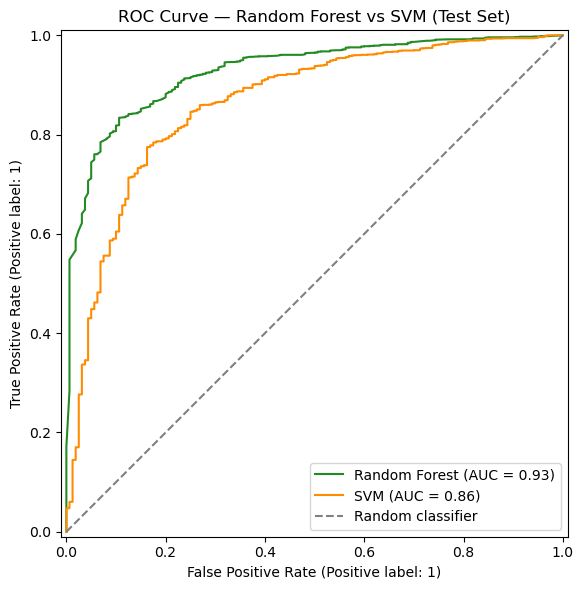

Plot saved to results/


In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax, plot_chance_level=False)
ax.lines[-1].set_color('forestgreen')

RocCurveDisplay.from_predictions(y_test, svm_proba, name='SVM', ax=ax, plot_chance_level=False)
ax.lines[-1].set_color('darkorange')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
ax.set_title('ROC Curve — Random Forest vs SVM (Test Set)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/04_roc_curves.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 10. Confusion Matrices

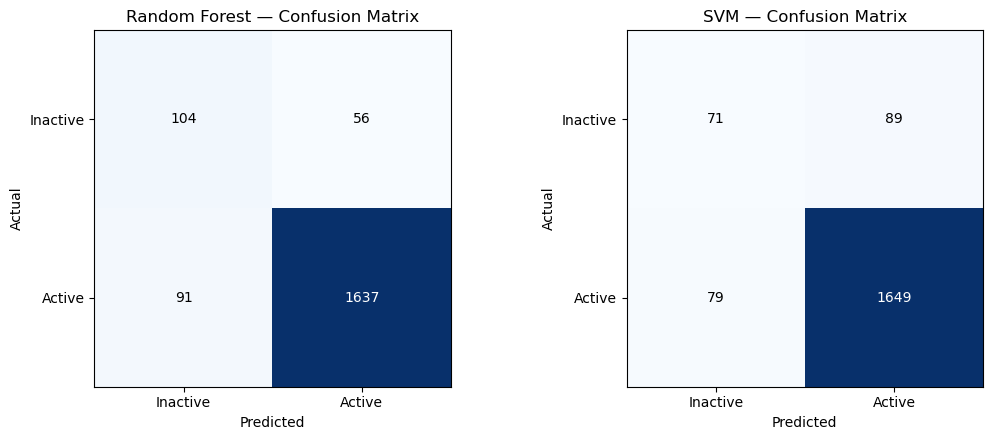

Plot saved to results/


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('SVM', svm_pred)]):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Inactive', 'Active'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Inactive', 'Active'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../results/04_confusion_matrices.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 11. Feature Importance (Random Forest)

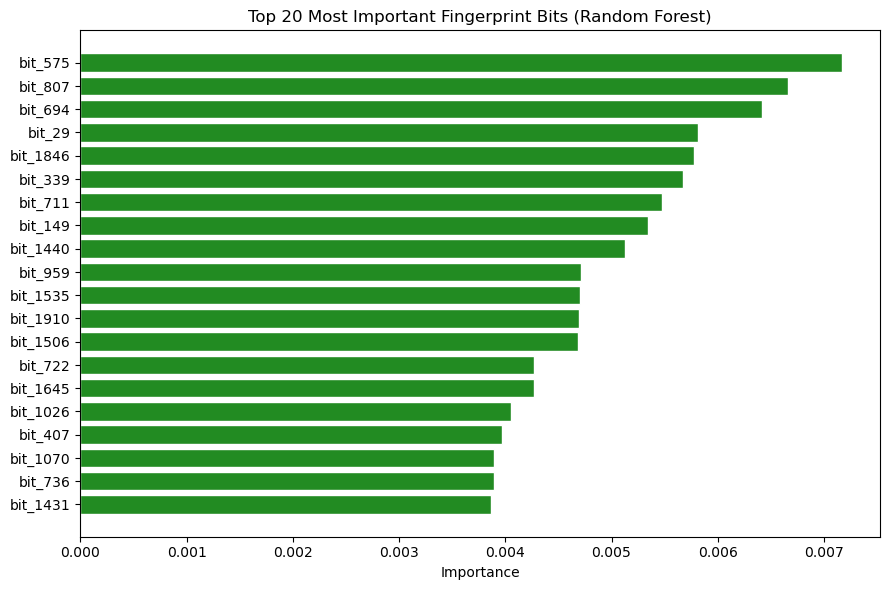

Plot saved to results/

Top bit: bit_575


In [12]:
importances = rf.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(9, 6))
plt.barh(
    [bit_cols[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color='forestgreen', edgecolor='white'
)
plt.title(f'Top {top_n} Most Important Fingerprint Bits (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/04_feature_importance.png', dpi=150)
plt.show()
print('Plot saved to results/')
print(f'\nTop bit: {bit_cols[top_idx[0]]}')

bit_575: atom 20, radius 2


[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerator
[10:36:38] DEPRECATION WARNING: please use MorganGenerat

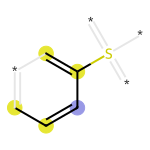

In [14]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display
import pandas as pd

df_smiles = pd.read_csv('../data/processed/btk_curated.csv')

bit_to_inspect = 575

def get_bit_info(smi, bit_id, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits, bitInfo=bit_info)
    if bit_id in bit_info:
        return mol, bit_info[bit_id]
    return None

example = None
for smi in df_smiles['canonical_smiles']:
    result = get_bit_info(smi, bit_to_inspect)
    if result is not None:
        example = result
        break

if example:
    mol, atom_radius_list = example
    atom_idx, radius = atom_radius_list[0]
    img = Draw.DrawMorganBit(mol, bit_to_inspect, {bit_to_inspect: atom_radius_list})
    if hasattr(img, 'save'):
        img.save('../results/04_bit575_substructure.png')
    else:
        with open('../results/04_bit575_substructure.png', 'wb') as f:
            f.write(img.data if hasattr(img, 'data') else img)
    print(f'bit_{bit_to_inspect}: atom {atom_idx}, radius {radius}')
    display(img)

## 12. Save Trained Models

In [13]:
joblib.dump(rf, '../models/rf_btk_classifier.pkl')
joblib.dump(svm, '../models/svm_btk_classifier.pkl')

print('Models saved:')
print('  models/rf_btk_classifier.pkl')
print('  models/svm_btk_classifier.pkl')

Models saved:
  models/rf_btk_classifier.pkl
  models/svm_btk_classifier.pkl


## Observations

## Observations: Random Forest vs SVM

### Performance comparison (test set)

| Metric | Random Forest | SVM (subsample n=3,000) |
|--------|---------------|--------------------------|
| AUC-ROC | **0.928** | 0.863 |
| F1-score | **0.957** | 0.952 |
| Precision | **0.967** | 0.949 |
| Recall | 0.947 | **0.954** |
| MCC | **0.547** | 0.410 |

**Random Forest outperformed SVM on every metric except recall**
(0.947 vs 0.954 — a negligible 0.7 percentage point difference).
The MCC gap is the most telling: 0.547 vs 0.410 — a difference of
13.7 percentage points that the F1 scores (0.957 vs 0.952) would not
reveal. This confirms RF handles the severe 91.5/8.5 class imbalance
more effectively than SVM.

**Note on SVM training:** SVM was trained on a stratified subsample of
3,000 molecules (from 7,548 training examples) due to the computational
cost of kernel methods at this dataset size. This means the SVM comparison
is not perfectly fair — RF had access to 2.5x more training data — but
reflects a realistic constraint when using kernel SVMs in practice.

### Why MCC matters here

With 91.5% active / 8.5% inactive, a naive classifier predicting
"active" for everything would achieve F1 ≈ 0.956 — nearly identical
to our SVM's F1 of 0.952. MCC penalizes this behavior because it
accounts for all four quadrants of the confusion matrix. An MCC of
0.547 (RF) vs near-zero (for a naive classifier) demonstrates the
model is genuinely learning to distinguish active from inactive
compounds, not just exploiting the class imbalance.

### Most important fingerprint feature: bit_575

The top feature identified by the Random Forest is **bit_575**,
decoded via RDKit as an **aryl sulfonyl substructure** — an aromatic
ring with an S directly attached bearing two double-bonded oxygens
(–Ar–SO₂–). This is consistent with sulfonyl and sulfonamide groups
(–SO₂–NH–) commonly found in kinase inhibitors, where they:
- Act as hydrogen-bond acceptors via the sulfonyl oxygens
- Improve aqueous solubility
- Interact with residues in the ATP-binding hinge region of the kinase domain

Notably, this differs from the top feature in the previous (incorrect
mTOR) dataset, where bit_56 (urea/amide) dominated. The shift to an
aryl sulfonyl motif with the correct BTK data is chemically meaningful
— sulfonyl-containing scaffolds are well-represented among published
BTK inhibitors, and their prominence here validates that the model
learned a real structure-activity pattern specific to BTK.

### Conclusion

Random Forest is the stronger model for this dataset and task —
higher AUC, higher MCC, faster training, and more interpretable
feature importance. SVM remains competitive on F1 and recall but
shows a substantially lower MCC and required subsampling to run
in feasible time.

**Next steps (notebooks 05–07):**
- Regression: predict continuous pIC50 values (notebook 05)
- Hyperparameter tuning (notebook 06)
- Class imbalance strategies with focus on improving MCC (notebook 07)


## Summary

| Item | Value |
|------|-------|
| Training set | *(see output)* molecules |
| Test set | *(see output)* molecules |
| CV strategy | 5-fold Stratified |
| RF — CV AUC | *(see output)* |
| SVM — CV AUC | *(see output)* |
| RF — Test AUC | *(see output)* |
| SVM — Test AUC | *(see output)* |
| RF — Test MCC | *(see output)* |
| SVM — Test MCC | *(see output)* |

**Next:** `05_regression.ipynb` — predict continuous pIC50 values.